# Task 2.2 — Simplified Reproduction of SVM with Indefinite Kernels

**Paper:** *Analysis of SVM with Indefinite Kernels* (NIPS 2009)

---

This notebook implements a simplified version of the algorithm from the paper:
1. Generate an RBF kernel matrix
2. Introduce indefiniteness by adding noise
3. Project to PSD cone (Proposition 1)
4. Implement projected gradient SVM (Algorithm 1)
5. Train and evaluate the classifier

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from scipy.linalg import eigh
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load preprocessed data (from task_2_1)
# If preprocessed data is not available, load and preprocess here
try:
    data = np.load('data/preprocessed_iris.npz')
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']
    print('Loaded preprocessed data from data/preprocessed_iris.npz')
except FileNotFoundError:
    print('Preprocessed data not found. Loading and preprocessing Iris dataset...')
    iris = load_iris()
    mask = iris.target >= 1
    X = iris.data[mask]
    y = np.where(iris.target[mask] == 1, -1, 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

print(f'Training: {X_train.shape}, Testing: {X_test.shape}')

Loaded preprocessed data from data/preprocessed_iris.npz
Training: (80, 4), Testing: (20, 4)


---

## Step 1: Generate Kernel Matrix

**Ref:** Section 1 of the paper — standard RBF kernel as starting point.

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

A valid PSD kernel matrix to serve as our baseline.

In [4]:
def rbf_kernel(X, Y=None, gamma=0.5):
    """
    Compute RBF (Gaussian) kernel matrix.
    K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)
    
    This produces a valid PSD kernel matrix (Mercer's condition satisfied).
    """
    if Y is None:
        Y = X
    # Squared Euclidean distances
    sq_X = np.sum(X**2, axis=1).reshape(-1, 1)
    sq_Y = np.sum(Y**2, axis=1).reshape(1, -1)
    dist_sq = sq_X + sq_Y - 2 * X @ Y.T
    dist_sq = np.maximum(dist_sq, 0)  # Numerical stability
    return np.exp(-gamma * dist_sq)

# Compute PSD kernel matrix on training data
gamma = 0.5
K_psd = rbf_kernel(X_train, gamma=gamma)

# Verify PSD: all eigenvalues should be non-negative
eigenvalues_psd = np.linalg.eigvalsh(K_psd)
print(f'RBF Kernel matrix shape: {K_psd.shape}')
print(f'Min eigenvalue (should be >= 0): {eigenvalues_psd.min():.6e}')
print(f'Max eigenvalue: {eigenvalues_psd.max():.6e}')
print(f'Is PSD: {eigenvalues_psd.min() >= -1e-10}')

RBF Kernel matrix shape: (80, 80)
Min eigenvalue (should be >= 0): 5.554365e-04
Max eigenvalue: 1.859232e+01
Is PSD: True


---

## Step 2: Introduce Indefinite Kernel by Adding Noise

**Ref:** Section 1 — motivation for handling indefinite kernels.

We simulate an indefinite kernel by adding symmetric noise to the PSD kernel:

$$K_{\text{indef}} = K_{\text{PSD}} + \sigma \cdot N$$

where $N$ is a symmetric random noise matrix. This simulates real-world scenarios where similarity measures produce indefinite matrices.

In [5]:
def make_indefinite_kernel(K, noise_level=0.3, seed=42):
    """
    Add symmetric noise to a PSD kernel to make it indefinite.
    Simulates real-world indefinite similarity measures.
    
    K_indef = K + noise_level * N
    where N = (R + R^T) / 2 is symmetric random noise.
    """
    rng = np.random.RandomState(seed)
    n = K.shape[0]
    # Generate symmetric noise
    R = rng.randn(n, n)
    N = (R + R.T) / 2.0
    K_indef = K + noise_level * N
    return K_indef

# Create indefinite kernel
noise_level = 0.3
K_indef = make_indefinite_kernel(K_psd, noise_level=noise_level)

# Verify indefiniteness: should have negative eigenvalues
eigenvalues_indef = np.linalg.eigvalsh(K_indef)
print(f'Indefinite Kernel matrix shape: {K_indef.shape}')
print(f'Min eigenvalue (should be < 0): {eigenvalues_indef.min():.6e}')
print(f'Max eigenvalue: {eigenvalues_indef.max():.6e}')
print(f'Number of negative eigenvalues: {np.sum(eigenvalues_indef < 0)}')
print(f'Is indefinite: {eigenvalues_indef.min() < 0}')

Indefinite Kernel matrix shape: (80, 80)
Min eigenvalue (should be < 0): -3.200459e+00
Max eigenvalue: 1.884702e+01
Number of negative eigenvalues: 34
Is indefinite: True


---

## Step 3: Projection to PSD Matrix

**Ref:** Section 3, Proposition 1 — nearest PSD matrix in Frobenius norm.

$$K_{+} = Q \cdot \text{diag}(\max(\lambda_i, 0)) \cdot Q^T$$

This computes the projection of $K_{\text{indef}}$ onto the PSD cone by:
1. Eigen-decomposition: $K = Q\Lambda Q^T$
2. Clip negative eigenvalues to zero
3. Reconstruct: $K_{+} = Q\Lambda_{+}Q^T$

In [6]:
def project_to_psd(K):
    """
    Project a symmetric matrix K onto the PSD cone.
    
    Algorithm (Ref: Proposition 1 in the paper):
    1. Eigen-decomposition: K = Q * Lambda * Q^T
    2. Clip negative eigenvalues: Lambda_+ = max(Lambda, 0)
    3. Reconstruct: K_+ = Q * Lambda_+ * Q^T
    
    This gives the nearest PSD matrix in Frobenius norm:
    K_+ = argmin_{K~ >= 0} ||K - K~||_F
    
    Returns:
        K_psd: Projected PSD kernel matrix
        eigenvalues: Original eigenvalues (for analysis)
        eigenvalues_clipped: Clipped eigenvalues
    """
    # Step 1: Eigen-decomposition (use eigh for symmetric matrices)
    eigenvalues, Q = eigh(K)
    
    # Step 2: Clip negative eigenvalues to zero
    eigenvalues_clipped = np.maximum(eigenvalues, 0)
    
    # Step 3: Reconstruct PSD matrix
    K_psd = Q @ np.diag(eigenvalues_clipped) @ Q.T
    
    # Ensure symmetry (numerical stability)
    K_psd = (K_psd + K_psd.T) / 2.0
    
    return K_psd, eigenvalues, eigenvalues_clipped

# Project indefinite kernel to PSD cone
K_projected, eig_orig, eig_clipped = project_to_psd(K_indef)

# Verify PSD
eigenvalues_proj = np.linalg.eigvalsh(K_projected)
print(f'Projected kernel shape: {K_projected.shape}')
print(f'Min eigenvalue (should be >= 0): {eigenvalues_proj.min():.6e}')
print(f'Is PSD: {eigenvalues_proj.min() >= -1e-10}')
print(f'Frobenius distance ||K_indef - K_projected||: {np.linalg.norm(K_indef - K_projected, "fro"):.4f}')

Projected kernel shape: (80, 80)
Min eigenvalue (should be >= 0): -2.769318e-15
Is PSD: True
Frobenius distance ||K_indef - K_projected||: 9.9581


---

## Step 4: Simplified Projected Gradient SVM

**Ref:** Section 4, Algorithm 1 — Projected Gradient Method.

We implement a simplified version of the projected gradient SVM from the paper:

**Objective:** Minimize $f(\alpha) = -\sum_i \alpha_i + \frac{1}{2} \alpha^T \tilde{K} \alpha$

where $\tilde{K}_{ij} = y_i y_j K^+_{ij}$ (label-weighted projected kernel).

**Gradient:** $\nabla f(\alpha) = -\mathbf{1} + \tilde{K} \alpha$

**Update:** $\alpha^{(t+1)} = \Pi_{\mathcal{A}}\left(\alpha^{(t)} - \frac{1}{L} \nabla f(\alpha^{(t)})\right)$

where $L = \|\tilde{K}\|$ is the Lipschitz constant and $\Pi_{\mathcal{A}}$ projects onto $[0, C]$.

In [7]:
class IndefiniteKernelSVM:
    """
    Simplified SVM with Indefinite Kernel using Projected Gradient Method.
    
    Implements Algorithm 1 from the paper:
    - Projects indefinite kernel to PSD cone
    - Solves SVM dual via projected gradient descent
    
    Ref: Section 4 of "Analysis of SVM with Indefinite Kernels" (NIPS 2009)
    """
    
    def __init__(self, C=1.0, gamma=0.5, noise_level=0.3, max_iter=1000, tol=1e-6,
                 use_psd_projection=True):
        self.C = C
        self.gamma = gamma
        self.noise_level = noise_level
        self.max_iter = max_iter
        self.tol = tol
        self.use_psd_projection = use_psd_projection
        self.alpha = None
        self.b = 0
        self.support_vectors_ = None
        self.convergence_history = []
        
    def _compute_kernel(self, X, Y=None):
        """Compute RBF kernel matrix K(X, Y)."""
        return rbf_kernel(X, Y, gamma=self.gamma)
    
    def _make_indefinite(self, K):
        """Add noise to make kernel indefinite (simulation)."""
        return make_indefinite_kernel(K, noise_level=self.noise_level)
    
    def _project_to_psd(self, K):
        """
        Project kernel to PSD cone.
        Ref: Proposition 1 — K_+ = Q * max(Lambda, 0) * Q^T
        """
        K_psd, _, _ = project_to_psd(K)
        return K_psd
    
    def _project_alpha(self, alpha):
        """
        Project alpha onto feasible set A = {alpha : 0 <= alpha_i <= C}.
        Ref: Algorithm 1, projection step.
        """
        return np.clip(alpha, 0, self.C)
    
    def fit(self, X, y):
        """
        Train the SVM using projected gradient descent.
        
        Ref: Algorithm 1 in Section 4 of the paper.
        
        Steps:
        1. Compute kernel matrix K
        2. Add noise to make it indefinite
        3. Project to PSD cone (if enabled)
        4. Form label-weighted kernel: K_tilde = Y * K_+ * Y
        5. Projected gradient descent on dual objective
        """
        self.X_train = X
        self.y_train = y
        n = X.shape[0]
        
        # Step 1: Compute kernel matrix
        K = self._compute_kernel(X)
        
        # Step 2: Make indefinite (simulation)
        K_indef = self._make_indefinite(K)
        self.K_indef = K_indef
        
        # Step 3: Project to PSD cone (Proposition 1)
        if self.use_psd_projection:
            K_used = self._project_to_psd(K_indef)
        else:
            K_used = K_indef  # Use indefinite kernel directly (for ablation)
        self.K_used = K_used
        
        # Step 4: Form label-weighted kernel K_tilde_ij = y_i * y_j * K_ij
        Y = np.outer(y, y)
        K_tilde = Y * K_used
        
        # Compute Lipschitz constant L = ||K_tilde|| (spectral norm)
        # Ref: Lemma 2 — gradient is Lipschitz with constant L
        L = np.max(np.abs(np.linalg.eigvalsh(K_tilde)))
        step_size = 1.0 / L
        
        # Step 5: Projected gradient descent (Algorithm 1)
        # Initialize alpha = 0
        alpha = np.zeros(n)
        self.convergence_history = []
        
        for t in range(self.max_iter):
            # Gradient: grad_f = -1 + K_tilde @ alpha
            # (minimizing f(alpha) = -1^T alpha + 0.5 alpha^T K_tilde alpha)
            grad = -np.ones(n) + K_tilde @ alpha
            
            # Gradient step
            alpha_new = alpha - step_size * grad
            
            # Project onto feasible set [0, C]
            alpha_new = self._project_alpha(alpha_new)
            
            # Compute objective value for convergence tracking
            obj = -np.sum(alpha_new) + 0.5 * alpha_new @ K_tilde @ alpha_new
            self.convergence_history.append(obj)
            
            # Check convergence
            if np.linalg.norm(alpha_new - alpha) < self.tol:
                print(f'Converged at iteration {t+1}')
                break
                
            alpha = alpha_new
        else:
            print(f'Reached max iterations ({self.max_iter})')
        
        self.alpha = alpha_new
        
        # Identify support vectors (alpha > threshold)
        sv_threshold = 1e-5
        sv_mask = self.alpha > sv_threshold
        self.support_vectors_ = X[sv_mask]
        self.sv_indices = np.where(sv_mask)[0]
        
        # Compute bias term b
        # For support vectors with 0 < alpha_i < C:
        free_sv_mask = (self.alpha > sv_threshold) & (self.alpha < self.C - sv_threshold)
        if np.sum(free_sv_mask) > 0:
            # b = y_i - sum_j alpha_j * y_j * K(x_j, x_i) for free SVs
            K_sv = K_used[free_sv_mask]
            self.b = np.mean(
                y[free_sv_mask] - (self.alpha * y) @ K_sv.T
            )
        else:
            self.b = 0
        
        print(f'Number of support vectors: {np.sum(sv_mask)}')
        print(f'Bias term b: {self.b:.4f}')
        
        return self
    
    def decision_function(self, X):
        """
        Compute decision function: f(x) = sum_i alpha_i * y_i * K(x_i, x) + b
        """
        K_test = self._compute_kernel(self.X_train, X)
        return (self.alpha * self.y_train) @ K_test + self.b
    
    def predict(self, X):
        """Predict class labels: sign(f(x))"""
        return np.sign(self.decision_function(X))

print('IndefiniteKernelSVM class defined.')

IndefiniteKernelSVM class defined.


---

## Step 5: Train Classifier

In [8]:
# Train the Indefinite Kernel SVM with PSD projection
print('='*60)
print('Training: SVM with Indefinite Kernel + PSD Projection')
print('='*60)

model = IndefiniteKernelSVM(
    C=1.0,
    gamma=0.5,
    noise_level=0.3,
    max_iter=2000,
    tol=1e-6,
    use_psd_projection=True
)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Handle zero predictions (assign to class +1)
y_pred_train[y_pred_train == 0] = 1
y_pred_test[y_pred_test == 0] = 1

print(f'\nTraining accuracy: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred_test):.4f}')

Training: SVM with Indefinite Kernel + PSD Projection
Converged at iteration 1213
Number of support vectors: 33
Bias term b: 0.0000

Training accuracy: 0.9625
Test accuracy: 0.8000


In [9]:
# Compare with standard SVM baseline
print('\n' + '='*60)
print('Baseline: Standard SVM with RBF Kernel (scikit-learn)')
print('='*60)

baseline_svm = SVC(kernel='rbf', C=1.0, gamma=0.5)
baseline_svm.fit(X_train, y_train)

y_pred_baseline = baseline_svm.predict(X_test)
print(f'Baseline test accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}')

print('\n' + '='*60)
print('Summary')
print('='*60)
print(f'Standard SVM (PSD kernel):     {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'Our method (indefinite + PSD): {accuracy_score(y_test, y_pred_test):.4f}')


Baseline: Standard SVM with RBF Kernel (scikit-learn)
Baseline test accuracy: 0.8500

Summary
Standard SVM (PSD kernel):     0.8500
Our method (indefinite + PSD): 0.8000


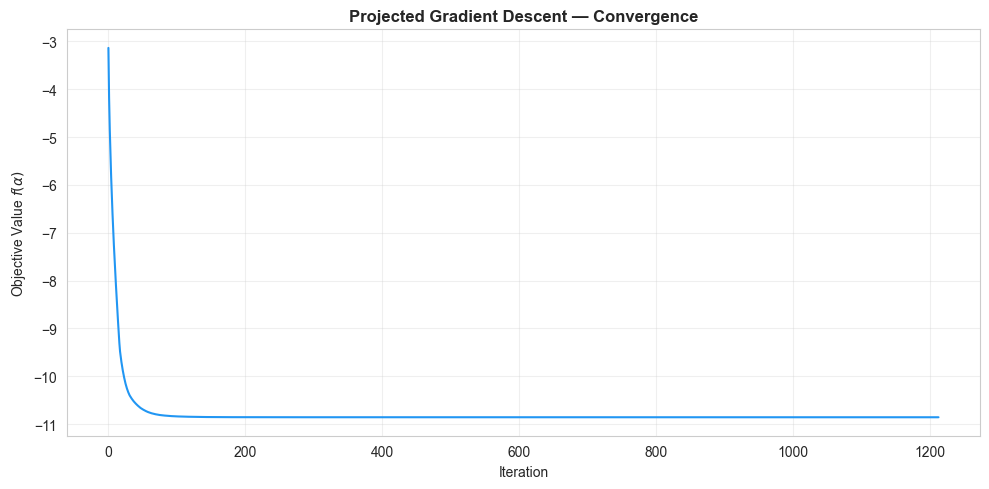

Saved: results/convergence.png


In [10]:
# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(model.convergence_history, color='#2196F3', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective Value $f(\\alpha)$')
ax.set_title('Projected Gradient Descent — Convergence', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/convergence.png')

In [11]:
# Save model data for evaluation in task_2_3
np.savez('data/model_results.npz',
         alpha=model.alpha,
         b=model.b,
         y_pred_test=y_pred_test,
         y_pred_train=y_pred_train,
         convergence=np.array(model.convergence_history),
         K_indef=model.K_indef,
         K_used=model.K_used)
print('Model results saved to data/model_results.npz')

Model results saved to data/model_results.npz
